# Geospatial Python: Raster Data
This notebook introduces `rasterio` for processing gridded spatial data (satellite imagery, digital elevation models, etc.).

`rasterio` is a powerful Python library built on top of GDAL and NumPy. It allows us to read satellite images as matrices of numbers, do math on those numbers, and export new images.

*Reference:* [Raster Data Analysis by Geospatialyst](https://geospatialyst.readthedocs.io/en/latest/Content/Lesson/geo-python-course/06.Raster-data-analysis.html)

In [ ]:
# Make sure you have these packages
uv add rasterio matplotlib numpy

---

## 1. Introduction to Raster Data

### 1.1 What is a Raster?
While vector data uses discrete coordinates to draw shapes, raster data represents the world as a continuous grid of cells (or pixels).

Each pixel contains a numerical value. In satellite imagery, these values often represent the reflectance of light at specific wavelengths (bands). Different satellites number their bands differently. For the sample Landsat image we are using today, Red is Band 3, and NIR is Band 4.

- **Band 2 Green** (0.52 - 0.60 µm) 30 m
- **Band 3 Red** (0.63 - 0.69 µm) 30 m
- **Band 4 Near-Infrared** (0.77 - 0.90 µm) 30 m

*Source:* [Landsat 7](https://www.usgs.gov/landsat-missions/landsat-7)

### 1.2 Transitioning from GEE to Rasterio
We can download the GeoTIFF files to the computer first and then use `rasterio` to read them into memory as `numpy` arrays.

### 1.3 Downloading Sample Data
We first download a sample multispectral satellite image (Landsat 7) directly into our `data/` folder.

In [1]:
import os
import urllib.request

os.makedirs('data', exist_ok=True)

url = "https://github.com/Automating-GIS-processes/CSC18/raw/master/data/Helsinki_masked_p188r018_7t20020529_z34__LV-FIN.tif"
raster_fp = "data/sample_landsat.tif"

print("Downloading sample satellite image...")
urllib.request.urlretrieve(url, raster_fp)
print(f"Download complete! Saved to {raster_fp}")

Download complete! Saved to data/sample_landsat.tif


---

## 2. Reading Raster Properties (Metadata)
Before looking at the pixels, we need to understand the file. Raster files  carry hidden "metadata" that tells Python where this image belongs on the Earth and how many layers (bands) it has.

In [4]:
import rasterio

# Open the file in read mode
satellite_image = rasterio.open(raster_fp)

# Inspect its properties
print(f"Coordinate Reference System (CRS): {satellite_image.crs}")
print(f"\nDimensions: {satellite_image.width} columns x {satellite_image.height} rows")
print(f"\nNumber of bands: {satellite_image.count}")
print(f"\nBounding Box: {satellite_image.bounds}")

Coordinate Reference System (CRS): PROJCS["UTM Zone 0, Northern Hemisphere",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-183],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

Dimensions: 1288 columns x 1439 rows

Number of bands: 7

Bounding Box: BoundingBox(left=698592.0, bottom=6656859.0, right=735300.0, top=6697870.5)


In [7]:
# View all metadata at once using .meta
print(satellite_image.meta)

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 1288, 'height': 1439, 'count': 7, 'crs': CRS.from_wkt('PROJCS["UTM Zone 0, Northern Hemisphere",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-183],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(28.5, 0.0, 698592.0,
       0.0, -28.5, 6697870.5)}


---

## 3. Raster Algebra: Calculating NDVI

Since `rasterio` reads bands as `numpy` arrays, we can do math on millions of pixels instantly.

We will be calculating for the Normalized Difference Vegetation Index (NDVI) to detect healthy crops.
The formula is: `(NIR - Red) / (NIR + Red)`

Note: For the Landsat image, Red is Band 3, and NIR is Band 4.

In [10]:
import numpy as np

# Read Band 3 (Red) and Band 4 (NIR)
red = satellite_image.read(3).astype('float32')
nir = satellite_image.read(4).astype('float32')

# Create an empty array of zeros that is the exact same size as our image
ndvi = np.zeros_like(red)

# Create a True/False map of all the pixels where (nir + red) is NOT zero
valid_pixels = (nir + red) != 0

# Only calculate NDVI on those valid pixels 
# The background pixels will just stay as the 0s in step 2.
ndvi[valid_pixels] = (nir[valid_pixels] - red[valid_pixels]) / (nir[valid_pixels] + red[valid_pixels])

print(f"Max NDVI (Healthiest vegetation): {np.max(ndvi):.2f}")
print(f"Min NDVI (Water or Built-up): {np.min(ndvi):.2f}")

Max NDVI (Healthiest vegetation): 0.96
Min NDVI (Water or Built-up): -0.95


---

## 4. Visualizing Raster Data
Now that we have successfully calculated our NDVI array, we need to map it.

Because `ndvi` is just a standard `numpy` matrix, we can use `matplotlib` to plot it. We will apply a specific colormap to translate the numbers into intuitive colors:
- Values near -1 (Water/Roads) will be Red.
- Values near 0 (Bare Soil/Rock) will be Yellow.
- Values near +1 (Healthy Crops/Forest) will be Dark Green.

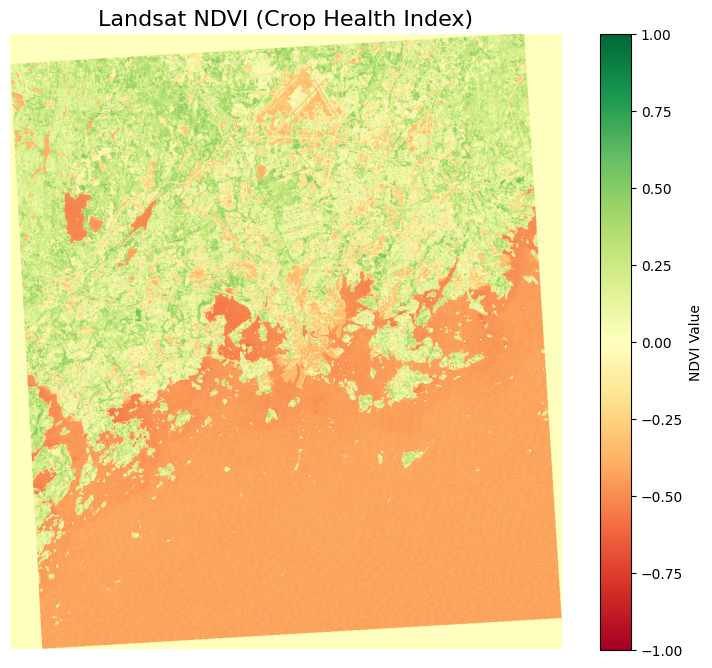

In [11]:
import matplotlib.pyplot as plt

# Initialize the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the NDVI array
# cmap='RdYlGn' stands for Red-Yellow-Green.
# vmin and vmax lock our color scale strictly between -1 and 1
im = ax.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)

# Add a colorbar to the side so we know what the colors mean
plt.colorbar(im, ax=ax, label="NDVI Value")

plt.title("Landsat NDVI (Crop Health Index)", fontsize=16)
ax.set_axis_off() # Hides the X/Y pixel numbers on the borders
plt.show()

---

## 5. Check-In Exercise: Calculating NDWI
PSA's Earth Engine script also calculated the Normalized Difference Water Index (NDWI) to identify water bodies and irrigation areas.

The formula for NDWI using a Landsat satellite image is:
`NDWI = (Green - NIR) / (Green + NIR)`

For the Landsat image:
- Band 2 is the Green band.
- Band 4 is the Near-Infrared (NIR) band.

**Tasks**
1. Read Band 2 (Green) from our satellite_image as a float32 array. *(You already have Band 4 saved as nir from earlier)*
2. Use `NumPy` to calculate the ndwi array.
3. Create a plot of your results. Use `cmap='Blues'` so that water shows up as dark blue.

In [ ]:
# Write code here


Max NDWI (Deepest water): 0.96


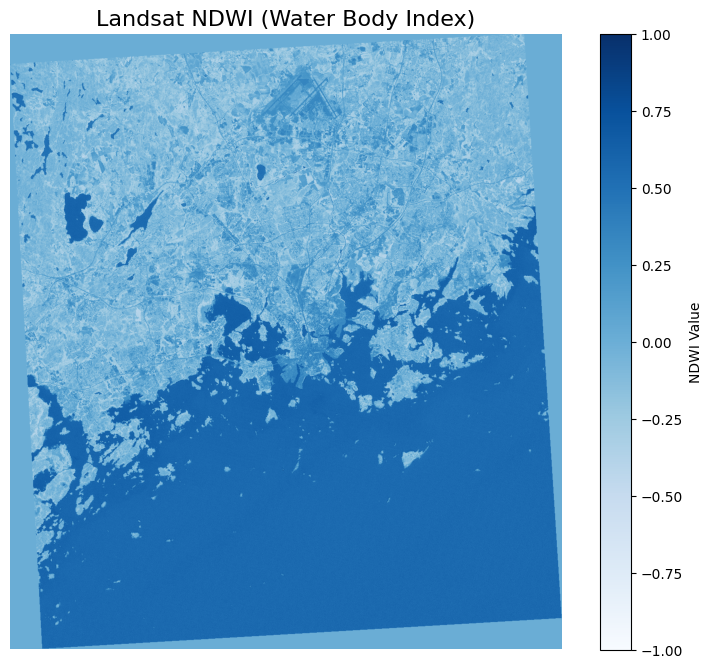

In [13]:
# Solution

import numpy as np
import matplotlib.pyplot as plt

# Task 1: Read the Green Band (Band 2)
# (Assuming nir was already read as Band 4 earlier)
green = satellite_image.read(2).astype('float32')

# Task 2: Calculate NDWI
# Formula: (Green - NIR) / (Green + NIR)

# Create an empty array of zeros
ndwi = np.zeros_like(green)

# Create mask where the denominator is NOT zero
valid_water_pixels = (green + nir) != 0

# Apply the math only to the valid pixels
ndwi[valid_water_pixels] = (green[valid_water_pixels] - nir[valid_water_pixels]) / (green[valid_water_pixels] + nir[valid_water_pixels])

print(f"Max NDWI (Deepest water): {np.max(ndwi):.2f}")

# Task 3: Visualize
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(ndwi, cmap='Blues', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="NDWI Value")

plt.title("Landsat NDWI (Water Body Index)", fontsize=16)
ax.set_axis_off()
plt.show()

---

## 5. Clipping Rasters with Vectors

To speed up analysis, we often "clip" or "crop" the image using a vector polygon (e.g., province boundary or a farm parcel) so we only analyze relevant pixels.

Because our sample image is in Finland, we can't use our Philippine farm shapefiles. Instead, we will use `shapely` to draw a quick custom Area of Interest (AOI) box right in the middle of our image, and use `rasterio.mask` to cut it out.

Original shape: (1439, 1288)
Clipped shape: (351, 352)


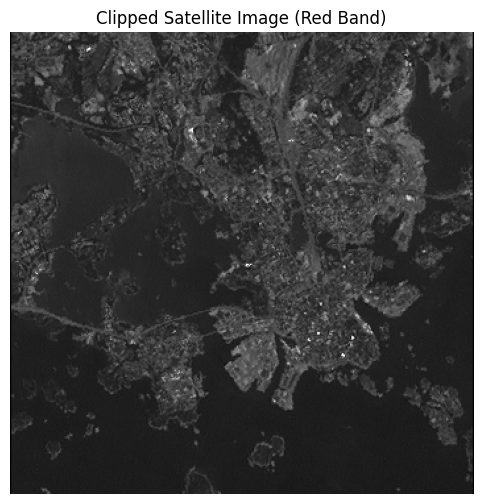

In [14]:
import geopandas as gpd
from shapely.geometry import box
import rasterio.mask
import matplotlib.pyplot as plt

# Get the boundaries of original satellite image
bounds = satellite_image.bounds
minx, miny, maxx, maxy = bounds.left, bounds.bottom, bounds.right, bounds.top

# Create a smaller bounding box in the center of the image
center_x = (minx + maxx) / 2
center_y = (miny + maxy) / 2
aoi_geom = box(center_x - 5000, center_y - 5000, center_x + 5000, center_y + 5000)

# Convert Shapely shape into a GeoDataFrame (so it has a CRS)
aoi_gdf = gpd.GeoDataFrame({'geometry': [aoi_geom]}, crs=satellite_image.crs)

# Perform the Clip
clipped_image_array, clipped_transform = rasterio.mask.mask(
    satellite_image, 
    aoi_gdf.geometry.values, 
    crop=True
)

print(f"Original shape: {satellite_image.shape}")
print(f"Clipped shape: {clipped_image_array.shape[1:]}")

# Visualize the clipped result
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(clipped_image_array[2], cmap='gray') # Band 3 (Red) is at index 2
plt.title("Clipped Satellite Image (Red Band)")
ax.set_axis_off()
plt.show()

---

## 6. Exporting Rasters
Exporting a raster requires three things:
1. The raw NumPy Array (the pixels).
2. The Transform (the math that maps the pixels to Earth coordinates).
3. The Metadata (CRS, width, height, and data type).

Let's save the clipped image we just created.

In [15]:
# Copy the metadata from the original image
out_meta = satellite_image.meta.copy()

# Update the metadata to match the smaller clipped image
out_meta.update({
    "driver": "GTiff",
    "height": clipped_image_array.shape[1],
    "width": clipped_image_array.shape[2],
    "transform": clipped_transform
})

# Define the export file path
export_fp = "data/clipped_helsinki.tif"

# Write the file
with rasterio.open(export_fp, "w", **out_meta) as dest:
    dest.write(clipped_image_array)

print(f"Clipped raster saved to {export_fp}")

Clipped raster saved to data/clipped_helsinki.tif


---

## 7. Short Exercises

### Exercise 1

1. Using the `ndvi` array we calculated in Section 3, create a **True/False boolean mask** called `dense_forest` for all pixels where the NDVI value is strictly greater than 0.7.
2. Use `np.sum()` on your new mask to count exactly how many pixels meet this criteria.

In [ ]:
# Write code here


In [16]:
# Solution

import numpy as np

# Task 1: Create the boolean mask (True if > 0.7, False otherwise)
dense_forest = ndvi > 0.7

# Task 2: Count the True values
# In Python, True = 1 and False = 0, so np.sum() counts how many pixels match
pixel_count = np.sum(dense_forest)

print(f"There are {pixel_count} pixels classified as highly dense forest.")

There are 22 pixels classified as highly dense forest.


### Exercise 2

Create a `matplotlib` **histogram** of the `ndvi` array.

Note:
- `matplotlib`'s histogram function requires a 1D (flat) list of numbers, not a 2D grid. Use the `.flatten()` method on your array first.
- Filter out exactly 0.0 values so the black background doesn't create a massive spike in your chart.

In [ ]:
# Write code here


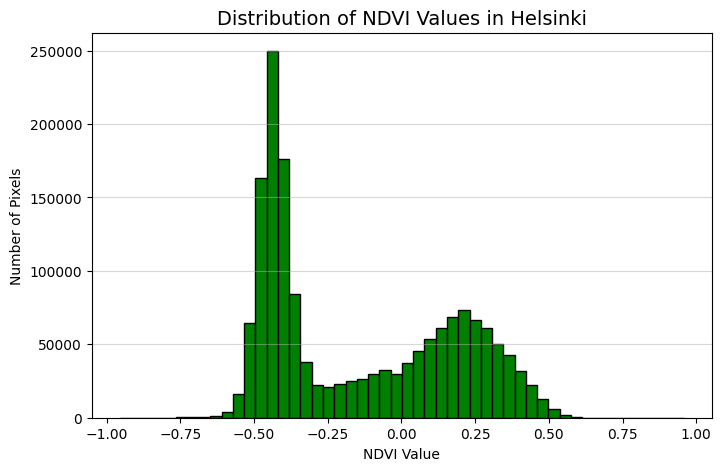

In [20]:
# Solution

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

# Filter out the pure 0 values
valid_ndvi = ndvi[ndvi != 0]

# Flatten the 2D array into a 1D list and plot the histogram
ax.hist(valid_ndvi.flatten(), bins=50, color='green', edgecolor='black')

plt.title("Distribution of NDVI Values in Helsinki", fontsize=14)
plt.xlabel("NDVI Value")
plt.ylabel("Number of Pixels")
plt.grid(axis='y', alpha=0.5)
plt.show()

---